# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Araceli Soto]

**Date:** [09/11/26]

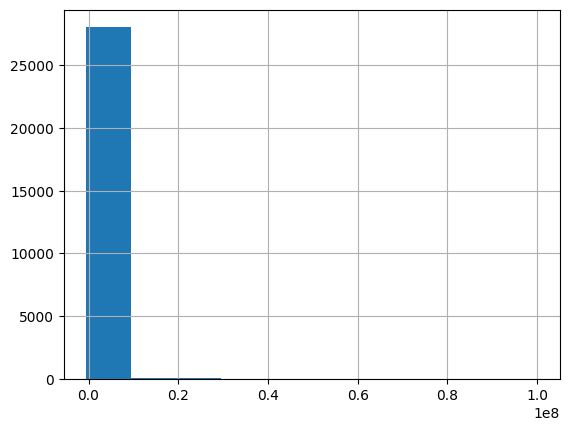

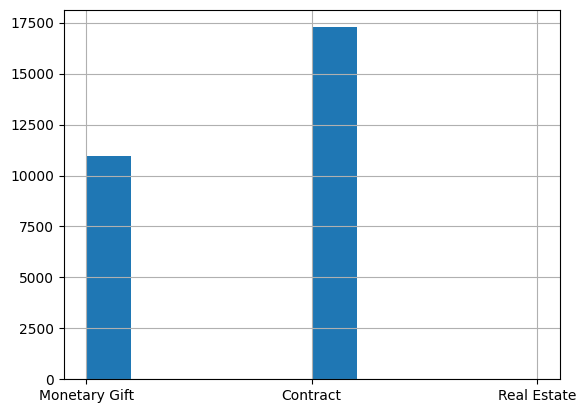

/Users/ara/Library/Python/3.9/lib/python/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


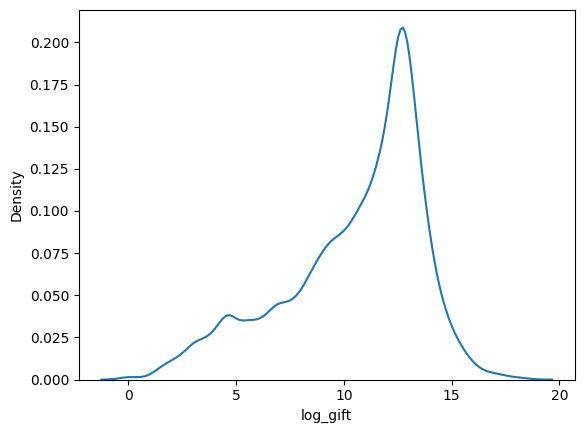

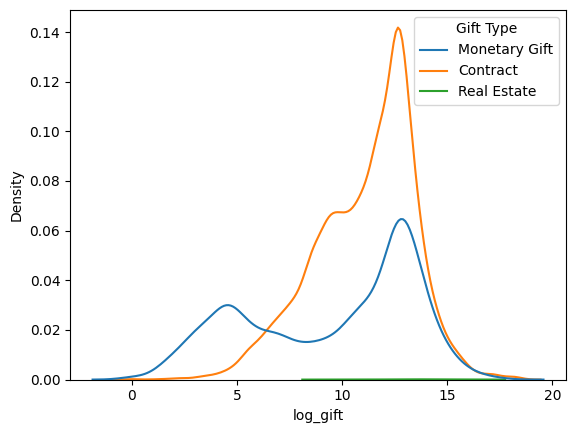

Giftor Name
Saudi Arabian Cultural Mission         480
Human Frontier Science Program         287
Anonymous                              262
Qatar Foundation                       261
Novartis Pharmaceuticals Corp          251
Acerta Pharma B.V.                     210
Royal Embassy of Saudi Arabia          210
Contracting Party                      143
Gwangju Institute of S&T               141
WSB Universities                       140
Qatar National Research Fund           124
Shire Human Genetics Therapies, Inc    108
RiMED Foundation                       106
Novartis                               105
Boehringer Ingelheim Pharmaceutical    104
Name: Foreign Gift Amount, dtype: int64

In [ ]:
# Your Phase 1 solution to the problem goes here.
#import

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('./data/ForeignGifts_edu.csv')
data.head() #to see the part of the data

#histogram plot explanation
data["Foreign Gift Amount"].hist()
plt.show()
# the variable "Foreign Gift Amount" is mostly concentrated around 0, reaching over 25000 which shows that the data is mostly 
#by the left side of the histogram with a few outliers on the right side of the historgram. 
# This shows that most of the foreign gifts are small in amount.

#gift type histogram plot explanation
data["Gift Type"].hist()
plt.show()
data["Gift Type"].value_counts()  # to see the counts of each gift type closely
# gift type shows that contract gift types is the most common gift type followed by monetary and real estate gift types.
# the least common gift type is the real estate gift type.

#KDE
data["log_gift"] = np.log(data["Foreign Gift Amount"].replace(0, np.nan).dropna())
sns.kdeplot(data=data, x="log_gift")
plt.show()

sns.kdeplot(data=data, x="log_gift", hue="Gift Type")
plt.show()
# i see different patterns of gift types in the plot with the contract gift type having the highest density
# is also more clearer to see comparared to the histogram plot because is not as cluttered.

#15 countries 
data.groupby('Country of Giftor').count()['Foreign Gift Amount'].sort_values(ascending=False).head(15)
data.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
#top giftors
data.groupby('Giftor Name').count()['Foreign Gift Amount'].sort_values(ascending=False).head(15)


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [17829ebf599a91bccfe077ea83b2237f86029a1f]
- **AI tool and model used:**[CHATGPT 5.6]

### *Prompts used

1. [“Here is my code. How do I improve it for this assignment?”]
2. ["how would that help my code?"]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1.Improve the histogram of Foreign Gift Amount by adding a title and axis labels so the visualization is easier to interpret.
2.Improve the gift-type analysis by using a bar chart of Gift Type counts instead of relying on hist(), since Gift Type is categorical data.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | ACCEPT / modify / reject | Adding titles and axis labels makes the histogram easier to understand. |
| 2 | ACCEPT / modify / reject | Gift Type is categorical, so a bar chart is more appropriate than a histogram |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('./data/ForeignGifts_edu.csv')
data.head() #to see the part of the data

#histogram plot explanation
data["Foreign Gift Amount"].hist()
plt.title("Distribution of Foreign Gift Amount")
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Frequency")
plt.show()

# the variable "Foreign Gift Amount" is mostly concentrated around 0, reaching over 25000
# which shows that the data is mostly by the left side of the histogram with a few outliers
# on the right side of the histogram. This shows that most of the foreign gifts are small in amount.

#gift type bar chart
data["Gift Type"].value_counts().plot(kind="bar")
plt.title("Number of Gifts by Gift Type")
plt.xlabel("Gift Type")
plt.ylabel("Number of Gifts")
plt.show()

data["Gift Type"].value_counts()  # to see the counts of each gift type closely

# gift type shows that contract gift types is the most common gift type followed by
# monetary and real estate gift types. The least common gift type is the real estate gift type.

#KDE
data["log_gift"] = np.log(data["Foreign Gift Amount"].replace(0, np.nan).dropna())
sns.kdeplot(data=data, x="log_gift")
plt.show()

sns.kdeplot(data=data, x="log_gift", hue="Gift Type")
plt.show()

# i see different patterns of gift types in the plot with the contract gift type having the highest density
# is also more clearer to see compared to the histogram plot because is not as cluttered.

#15 countries 
data.groupby('Country of Giftor').count()['Foreign Gift Amount'].sort_values(ascending=False).head(15)
data.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

#top giftors
data.groupby('Giftor Name').count()['Foreign Gift Amount'].sort_values(ascending=False).head(15)

### *Reflection on AI assistance
In your own words without generative AI.

As I used ChatGPT to look at the first phase of my code, it allowed me to see how I could improve it. One suggestion I accepted was adding a title and labels to my histogram because it made the graph easier to understand. I also accepted the suggestion to change the Gift Type histogram to a bar chart because Gift Type is categorical, so a bar chart made more sense than a histogram. I rejected the other suggestions because I wanted to keep most of my original code and approach. I think using ChatGPT was helpful because it allowed me to see small changes that could make my code and graphs clearer without completely changing how I did the assignment. I also made sure that the changes still worked with my original code and answered the questions from the assignment.